# Introduction to Scikit Learn(SK learn)

This notebook demonstrates some of the most useful functions of scikit-learn library

what we are going to cover:-
1. End-to-end scikit learn workflow
2. Getting data Ready
3. Choose the right estimator/algorithm for our problem
4. fit the model and use it to mak prediction
5. Evaluate the model
6. impoive a model
7. Save and load a trained model
8. Putting it all together

## 1. End-to-End scikit learn workflow

In [1]:
# 1. get the data ready
import pandas as pd
heart_diease = pd.read_csv("heart_disease.csv")
heart_diease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [2]:
# create x(feature matrix)
X = heart_diease.drop("target",axis=1)

# create Y (label matrix)
Y = heart_diease["target"]

In [3]:
# 2. choose the right model and hyper parameter
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

# we'll keep the default hyper paramters
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [4]:
# 3 fit the model to the training data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

In [5]:
# fit the model
clf.fit(x_train,y_train);

In [6]:
# make a prediction
y_labels = clf.predict(x_test)

In [7]:
y_labels

array([0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0])

In [8]:
y_test

269    0
52     1
152    1
250    0
166    0
      ..
175    0
162    1
221    0
14     1
226    0
Name: target, Length: 61, dtype: int64

In [9]:
# 4. Evaluate the model on training and test data
clf.score(x_train,y_train)

1.0

In [10]:
clf.score(x_test,y_test)

0.9344262295081968

In [11]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(classification_report(y_test,y_labels))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        28
           1       0.94      0.94      0.94        33

    accuracy                           0.93        61
   macro avg       0.93      0.93      0.93        61
weighted avg       0.93      0.93      0.93        61



In [12]:
confusion_matrix(y_test,y_labels)

array([[26,  2],
       [ 2, 31]])

In [13]:
accuracy_score(y_test,y_labels)

0.9344262295081968

In [14]:
# 5. Imporove a model
# Try different amount of hyper parameters
import numpy as np
np.random.seed(42)
for i in range(10,150,10):
    print(f"Trying models with {i} estimators.....")
    clf = RandomForestClassifier(n_estimators=i)
    clf.fit(x_train,y_train)
    print(f"Model Accuracy on test Sets: {clf.score(x_test,y_test)*100:.2f}%")
    print("")

Trying models with 10 estimators.....
Model Accuracy on test Sets: 85.25%

Trying models with 20 estimators.....
Model Accuracy on test Sets: 90.16%

Trying models with 30 estimators.....
Model Accuracy on test Sets: 88.52%

Trying models with 40 estimators.....
Model Accuracy on test Sets: 83.61%

Trying models with 50 estimators.....
Model Accuracy on test Sets: 90.16%

Trying models with 60 estimators.....
Model Accuracy on test Sets: 91.80%

Trying models with 70 estimators.....
Model Accuracy on test Sets: 88.52%

Trying models with 80 estimators.....
Model Accuracy on test Sets: 88.52%

Trying models with 90 estimators.....
Model Accuracy on test Sets: 91.80%

Trying models with 100 estimators.....
Model Accuracy on test Sets: 85.25%

Trying models with 110 estimators.....
Model Accuracy on test Sets: 83.61%

Trying models with 120 estimators.....
Model Accuracy on test Sets: 86.89%

Trying models with 130 estimators.....
Model Accuracy on test Sets: 85.25%

Trying models with 14

In [15]:
# 6. Save a model and load it
import pickle

pickle.dump(clf, open("Random-forest-model-1.pkl","wb"))

In [16]:
loaded_model = pickle.load(open("Random-forest-model-1.pkl","rb"))
loaded_model.score(x_test,y_test)

0.8852459016393442

In [17]:
# to ignore the wornings
import warnings
warnings.filterwarnings("default") # default, ignore

In [18]:
import sklearn
sklearn.show_versions()


System:
    python: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
executable: C:\Users\Savya Sapkota\Desktop\Machine_learning\Heart_Disease_Analysis\env\python.exe
   machine: Windows-10-10.0.19045-SP0

Python dependencies:
      sklearn: 1.8.0
          pip: 25.3
   setuptools: 80.9.0
        numpy: 2.3.5
        scipy: 1.16.3
       Cython: None
       pandas: 2.3.3
   matplotlib: 3.10.7
       joblib: 1.5.2
threadpoolctl: 3.5.0

Built with OpenMP: True

threadpoolctl info:
       user_api: blas
   internal_api: mkl
    num_threads: 2
         prefix: mkl_rt
       filepath: C:\Users\Savya Sapkota\Desktop\Machine_learning\Heart_Disease_Analysis\env\Library\bin\mkl_rt.2.dll
        version: 2025.0-Product
threading_layer: intel

       user_api: openmp
   internal_api: openmp
    num_threads: 4
         prefix: libiomp
       filepath: C:\Users\Savya Sapkota\Desktop\Machine_learning\Heart_Disease_Analysis\env\Library\bin\libiomp5md.d

In [19]:
what_we_are_going_to_cover = [
"0. End-to-end scikit learn workflow",
"1. Getting data Ready",
"2. Choose the right estimator/algorithm for our problem",
"3. fit the model and use it to mak prediction",
"4. impoive a model",
"5. Save and load a trained model",
"6. Putting it all together"
]

In [20]:
what_we_are_going_to_cover


['0. End-to-end scikit learn workflow',
 '1. Getting data Ready',
 '2. Choose the right estimator/algorithm for our problem',
 '3. fit the model and use it to mak prediction',
 '4. impoive a model',
 '5. Save and load a trained model',
 '6. Putting it all together']

In [21]:
# standaret imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
## 1. Getting our data ready to be used with machine learning
heart_diease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [23]:
X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]
X.head(),Y.head()

(   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
 0   63    1   3       145   233    1        0      150      0      2.3      0   
 1   37    1   2       130   250    0        1      187      0      3.5      0   
 2   41    0   1       130   204    0        0      172      0      1.4      2   
 3   56    1   1       120   236    0        1      178      0      0.8      2   
 4   57    0   0       120   354    0        1      163      1      0.6      2   
 
    ca  thal  
 0   0     1  
 1   0     2  
 2   0     2  
 3   0     2  
 4   0     2  ,
 0    1
 1    1
 2    1
 3    1
 4    1
 Name: target, dtype: int64)

In [24]:
# split the data into train and test sets
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

In [25]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [26]:
X.shape,Y.shape

((303, 13), (303,))

In [27]:
heart_diease.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

# 1.1 Make Sure its all numerical

In [28]:
car_sales = pd.read_csv("car-sales-extended.csv")
len(car_sales)

1000

In [29]:
car_sales.head()


,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [30]:
car_sales.dtypes


Make             object
Colour           object
Odometer (KM)     int64
Doors             int64
Price             int64
dtype: object

In [31]:
# split the data into X and Y
X = car_sales.drop("Price",axis=1)
Y = car_sales["Price"]

In [32]:
# split the data into train and test split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)


In [33]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestClassifier()

In [34]:
model.fit(x_train,y_train)

ValueError: could not convert string to float: 'Nissan'

In [101]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [102]:
# Convert string into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",one_hot,categorical_features)],remainder="passthrough")

transformed_x = transformer.fit_transform(X)
transformed_x

ValueError: A given column is not a column of the dataframe

In [ ]:
pd.DataFrame(transformed_x)

In [ ]:
# using pandas
dummies = pd.get_dummies(car_sales[["Make","Colour","Doors"]])
dummies

In [ ]:
np.random.seed(42)
x_train,x_test,y_train,y_test = train_test_split(transformed_x,Y,test_size=0.2)


In [ ]:
model = RandomForestRegressor()

In [ ]:
model.fit(x_train,y_train)

In [ ]:
model.score(x_test,y_test)

### 1.2 Dealing with missing values

1. Fill them with some values (Imputation).
2. Remove the samples with missing data altogether.

In [ ]:
car_sales_missing = pd.read_csv("car-sales-extended-missing-data.csv")

In [ ]:
car_sales_missing.head()

In [ ]:
car_sales_missing.isna().sum()

In [ ]:
# lets split the data into X and Y(features and labels)
X = car_sales_missing.drop("Price",axis=1)
Y = car_sales_missing["Price"]

In [ ]:
# lets try and convert out data to numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",one_hot,categorical_features)],remainder="passthrough")
transformed_x = transformer.fit_transform(X)
transformed_x

### Option 1: Dealing with missing values using Pandas

In [ ]:
# fill the make column
car_sales_missing["Make"] = car_sales_missing["Make"].fillna("Missing")

# fill the colour column
car_sales_missing["Colour"] = car_sales_missing["Colour"].fillna("Missing")

# fill the odometer column
car_sales_missing["Odometer (KM)"] = car_sales_missing["Odometer (KM)"].fillna(car_sales_missing["Odometer (KM)"].mean())

# fill the door columns
car_sales_missing["Doors"] = car_sales_missing["Doors"].fillna(4)


In [ ]:
car_sales_missing.isna().sum()

In [ ]:
# lets not fill price column insted lets remove it
car_sales_missing = car_sales_missing.dropna()

In [ ]:
car_sales_missing.isna().sum()

In [ ]:
len(car_sales_missing)

In [ ]:
# lets split the data into X and Y(features and labels)
X = car_sales_missing.drop("Price",axis=1)
Y = car_sales_missing["Price"]

In [ ]:
# lets try and convert out data to numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",one_hot,categorical_features)],remainder="passthrough")
transformed_x = transformer.fit_transform(car_sales_missing)
transformed_x

In [ ]:
pd.DataFrame(transformed_x)

### Option 2: Fill missing values with scikit learn

In [ ]:
car_sales_missing = pd.read_csv("car-sales-extended-missing-data.csv")
car_sales_missing.isna().sum()

In [ ]:
# lets remove rows with price values
car_sales_missing = car_sales_missing.dropna(subset=["Price"])
car_sales_missing.isna().sum()

In [ ]:
# split the data into x and y
X = car_sales_missing.drop("Price",axis=1)
Y = car_sales_missing["Price"]

In [ ]:
# fill missing value with sklearn
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# fill categirical values with 'missing' and numerical with 'mean'
cat_imputer = SimpleImputer(strategy="constant",fill_value="missing")
door_imputer = SimpleImputer(strategy="constant",fill_value=4)
num_imputer = SimpleImputer(strategy="mean")

# define columns
cat_features = ["Make","Colour"]
door_features = ["Doors"]
num_feature = ["Odometer (KM)"]


# create an imputer
imputer = ColumnTransformer([("cat_imputer",cat_imputer,cat_features),("door_imputer",door_imputer,door_features),("num_imputer",num_imputer,num_feature)])

# Transform the data
filled_x = imputer.fit_transform(X)
filled_x

In [ ]:
car_slaes_filled = pd.DataFrame(filled_x,columns=["Make","Colour","Doors","Odometer (KM)"])
car_slaes_filled.head()

In [ ]:
car_slaes_filled.isna().sum()

In [ ]:
# we have already seperated price as y so lets convert it into numeric values
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",one_hot,cat_features)],remainder="passthrough")
trnasformed_x = transformer.fit_transform(car_slaes_filled)
transformed_x


In [ ]:
# conver into train test split
np.random.seed(42)
model = RandomForestRegressor()
x_train,x_test,y_train,y_test = train_test_split(transformed_x,Y,test_size=0.2)
model.fit(x_train,y_train)

In [ ]:
model.score(x_test,y_test)

## 2. Choosing the right estimator/algorithm for your problem
Some things to note

* Sklearn refers machine learning model/algorithm as estimators.
* Classification problem - predicing category 0 or 1 (clf short for classifier)
* Regression Problem - predicting a number such as selling price of a car

### Picking a machine learning model for a regression problem

Let's use the california housing datasets

In [ ]:
# Get the cali housing dataset
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing

In [ ]:
housing_df = pd.DataFrame(housing["data"],columns=housing["feature_names"])

In [ ]:
housing_df

In [ ]:
housing_df["target"] = housing["target"]
housing_df = housing_df.drop("MedHouseVal",axis=1)

In [ ]:
housing_df

In [ ]:
housing_df.isna().sum()

In [ ]:
housing_df.dtypes

In [ ]:
# Import Algorithm

# setup random seed
np.random.seed(42)

# create the data
X = housing_df.drop("target",axis=1)
Y = housing_df["target"]

# split the data into train and test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

# instianciate and fit the model
from sklearn.linear_model import Ridge
model = Ridge()
model.fit(x_train,y_train)

# check the score on the test set
model.score(x_test,y_test)


In [ ]:
# lets try SVM
from sklearn.svm import SVR
model = SVR()
model.fit(x_train,y_train)
model.score(x_test,y_test)

In [ ]:
# lets try another (Lasso)
from sklearn.linear_model import Lasso
model  = Lasso()
model.fit(x_train,y_train)
model.score(x_test,y_test)

In [ ]:
# lets try random forest regressor from ensemble model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(x_train,y_train)
model.score(x_test,y_test)

In [ ]:
housing_df

In [ ]:
# full workflow
# import the model/estimator
from sklearn.ensemble import RandomForestRegressor

# create a random seed
np.random.seed(42)

# split the data into X anf Y (feature and label matrix)
X = housing_df.drop("target",axis=1)
Y = housing_df["target"]

# split the data into train and test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

# instianciate the model
model = RandomForestRegressor()

# fit the model
model.fit(x_train,y_train)

# Evaluate the model
model.score(x_test,y_test)

## 2.2 Picking a model for classification problem

In [ ]:
heart_diease

In [ ]:
len(heart_diease)

In [ ]:
# import linear svc
from sklearn.svm import LinearSVC
# setup random seed
np.random.seed(42)

# split the data into X and Y
X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]

# split the data into train and test split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

# instiancate the model
clf = LinearSVC()

# fit the model
clf.fit(x_train,y_train)

# Evaluate the model
clf.score(x_test,y_test)


In [ ]:
clf.get_params()

In [ ]:
# lets try ensemble methods
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

clf.fit(x_train,y_train)

clf.score(x_test,y_test)

## 3. Fit the model and make predictions

### 3.1 fitting the model to the data

Different Names for:

* 'X' = features, Freture Variables, data
* 'Y' = labels, targets, target variables

In [ ]:
# import linear svc
from sklearn.ensemble import RandomForestClassifier
# setup random seed
np.random.seed(42)

# split the data into X and Y
X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]

# split the data into train and test split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

# instiancate the model
clf = RandomForestClassifier()

# fit the model to the data
clf.fit(x_train,y_train)

# Evaluate the model
clf.score(x_test,y_test)


In [ ]:
X.head()


In [ ]:
Y.head()

### 3.2 Make predictions using machine learning model

2 ways to make a prediction
1. use Predict function
2. predict_proba()

In [ ]:
clf

In [ ]:
# use a trained model to make predictions
clf.predict(x_test)

In [ ]:
 np.array(y_test)

In [ ]:
# compare predictions to truth label to evaluate the model
y_preds = clf.predict(x_test)
np.mean(y_preds == y_test)

In [ ]:
clf.score(x_test,y_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_preds)

# Make prediction with preduct proba

## predict probe return probasbilities of classification labels

In [ ]:
clf.predict_proba(x_test[:5])

In [ ]:
#lets predict on the same data
clf.predict(x_test[:5])

# 'Predict()' can also be used for regression datasets

In [ ]:
housing_df.head()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
X = housing_df.drop("target",axis=1)
Y = housing_df["target"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

model = RandomForestRegressor()

model.fit(x_train,y_train)

y_preds = model.predict(x_test)

y_preds[:10]

In [ ]:
y_preds[:10]

In [ ]:
np.array(y_test[:10])

In [ ]:
len(y_preds), len(y_test)

In [ ]:
# average diffrernce between actual and predicted values
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_preds)


In [ ]:
housing_df_preds = model.predict(x_test)

In [ ]:
housing_df_target = housing_df["target"]

In [ ]:
housing_df_preds

In [ ]:
housing_df_target

In [ ]:
what_we_are_going_to_cover = ['0. End-to-end scikit learn workflow',
 '1. Getting data Ready',
 '2. Choose the right estimator/algorithm for our problem',
 '3. fit the model and use it to mak prediction',
 '4. Evaluate the model'                            
 '5. improve a model',
 '6. Save and load a trained model',
 '7. Putting it all together']

In [ ]:
what_we_are_going_to_cover

## 4. Evaluate a machin learning model

There are three inbuilt ways to evaluate the models
1. using built-in `Score()` Parameter
2. The `scoring()` parameter
3. Problem-specific metric functions

## 4.1 Evaluating a model with a `Score` method

In [ ]:
# using Score method
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

clf = RandomForestClassifier()

clf.fit(x_train,y_train)

clf.score(x_test,y_test)

In [ ]:
# The higest value for score method is 1.0 and lowest in 0.0
## something is fishy!!! ahh it is using training data to test it.
clf.score(x_train,y_train)

# lets use the `score()` on regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
X = housing_df.drop("target",axis=1)
Y = housing_df["target"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

model = RandomForestRegressor()

model.fit(x_train,y_train)

model.score(x_test,y_test)

## 4.2 Evaluating the model using `scoring()` parameter

In [ ]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

clf = RandomForestClassifier()

clf.fit(x_train,y_train)



In [ ]:
clf.score(x_test,y_test)

In [ ]:
cross_val_score(clf,X,Y)

![](Cross_validation.png)

In [ ]:
cross_val_score(clf,X,Y)


In [ ]:
cross_val_score(clf,X,Y, cv = 10)

In [ ]:
np.random.seed(42)

# single training and test split score
clf_single_score = clf.score(x_test,y_test)

# take a mean of five fold cross val score
clf_cross_val_score = np.mean(cross_val_score(clf,X,Y))

# compare the two
clf_cross_val_score,clf_single_score

In [ ]:
# default scoring parameter of classifier = mean accuracy
clf.score(x_test,y_test)

In [ ]:
# scoring parameter is set to None by default (mean accuracy)
cross_val_score(clf,X,Y,scoring=None)

### 4.2.1 Classification model evaluation metrics
1. Accuracy
2. Area uner ROC curve
3. COnfusion matrix
4. classification report

## 1. Accuracy

In [ ]:
heart_diease.head()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]

clf = RandomForestClassifier()

cross_val_score = cross_val_score(clf,X,Y)

In [ ]:
np.mean(cross_val_score)

In [ ]:
print(f"Heart Disease Classifier Accuracy: {np.mean(cross_val_score)* 100:.2f}%")

## Area under the ROC(Receiver Operating Characterstic curve)Curve(AUC/ROC Curve)
* Area Under Curve(AUC)
* ROC Curve

ROC curves are the comparision between models (TPR) and False POsitive rate (FPR)


In [103]:
#create X_test
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)
clf = RandomForestClassifier()
clf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [104]:
from sklearn.metrics import roc_curve

y_preds = clf.predict_proba(x_test)

y_preds[:10]


array([[0.7 , 0.3 ],
       [0.59, 0.41],
       [0.92, 0.08],
       [0.08, 0.92],
       [0.07, 0.93],
       [0.03, 0.97],
       [0.27, 0.73],
       [0.91, 0.09],
       [0.38, 0.62],
       [0.1 , 0.9 ]])

In [105]:
# probabilities of positive or 1 because it is comparision of true positive vs false positive got it positive positive(0: negative,1 :positive)
y_probs_positive = y_preds[:,1]
y_probs_positive[:10]

array([0.3 , 0.41, 0.08, 0.92, 0.93, 0.97, 0.73, 0.09, 0.62, 0.9 ])

In [106]:
# we can calculate fpr,tpr and threshold
fpr,tpr,threshold = roc_curve(y_test,y_probs_positive)

# check the false positive rates
fpr

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.03703704, 0.03703704, 0.07407407, 0.07407407, 0.11111111,
       0.11111111, 0.14814815, 0.14814815, 0.18518519, 0.22222222,
       0.2962963 , 0.2962963 , 0.33333333, 0.37037037, 0.48148148,
       0.51851852, 0.59259259, 0.7037037 , 0.81481481, 0.85185185,
       0.92592593, 1.        ])

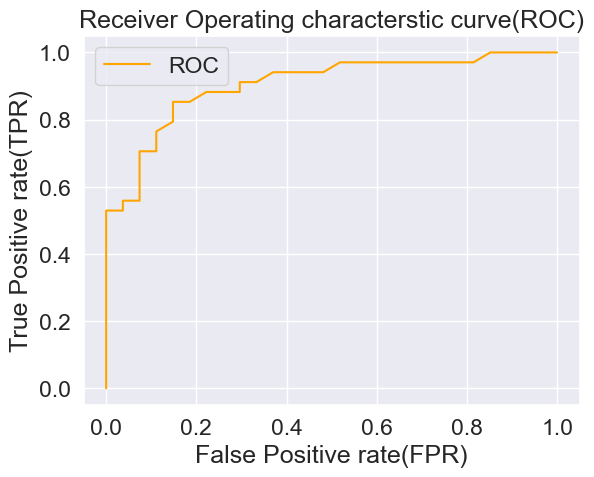

In [107]:
# create a function to plot a roc_curve
import matplotlib.pyplot as plt

def plot_roc_curve(frp,tpr):
    """
    Plots Roc curve given the false positive rate fpr and true positive rate tpr
    """

    # plot toc curve
    plt.plot(fpr,tpr,color="orange",label="ROC")

    # plot line with no predective power(baseline)
    # plt.plot([0,1],[0,1],color="darkblue",linestyle="--",label="Guessing")

    # customize the plot
    plt.xlabel("False Positive rate(FPR)")
    plt.ylabel("True Positive rate(TPR)")
    plt.title("Receiver Operating characterstic curve(ROC)")
    plt.legend()
plot_roc_curve(fpr,tpr)

In [108]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_probs_positive)


0.9046840958605664

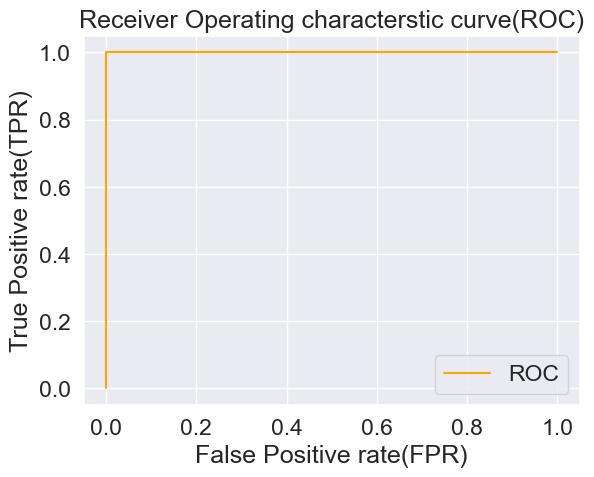

In [109]:
# lets see the perfect roc curve and auc score
fpr,tpr,threshold = roc_curve(y_test,y_test)
plot_roc_curve(fpr,tpr)

In [110]:
# perfect auc score 
roc_auc_score(y_test,y_test)

1.0

## Lets try confustion matrix

In [111]:
from sklearn.metrics import confusion_matrix
y_preds = clf.predict(x_test)

confusion_matrix(y_test,y_preds)

array([[23,  4],
       [ 7, 27]])

In [112]:
# visualide the confusion matrix with pd cross tab
pd.crosstab(y_test,y_preds,rownames = ["Actual Labels"],colnames=["Predicted Labels"])

Predicted Labels,0,1
Actual Labels,,
0,23,4
1,7,27


![](confusion_matrix.png)

In [113]:
#to install conda package frim jupter
# import sys
# !conda install --yes --prefix {sys.prefix} seaborn

<Axes: >

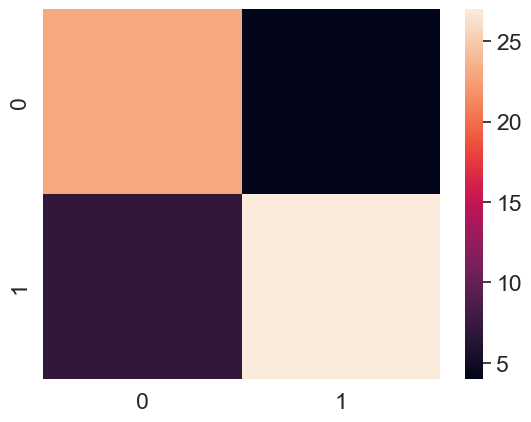

In [114]:
# make our confusion matrix more visual with seaborn heatmap
import seaborn as sns

# set the font scale
sns.set(font_scale=1.5)

conf_mat = confusion_matrix(y_test,y_preds)

sns.heatmap(conf_mat)

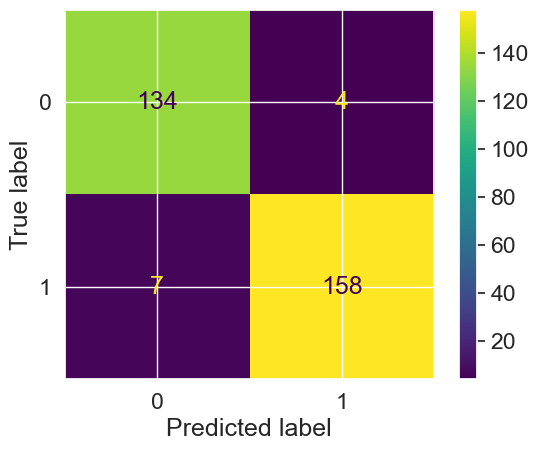

In [115]:
# this is from estimator
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(estimator=clf,X=X,y= Y)

In [116]:
len(heart_diease)

303

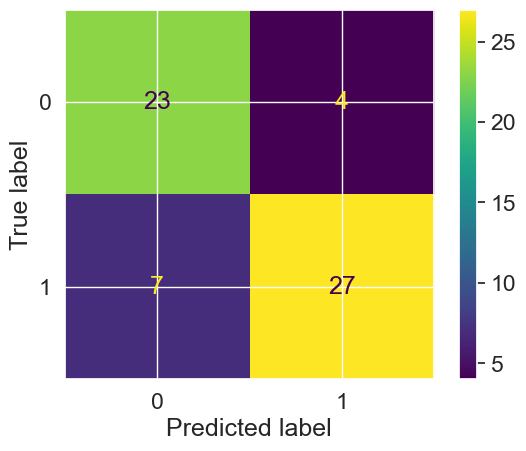

In [117]:
# this is from prediction
ConfusionMatrixDisplay.from_predictions(y_test,y_preds)

## Calssification report

In [118]:
from sklearn.metrics import classification_report
classification_report(y_test,y_preds)

'              precision    recall  f1-score   support\n\n           0       0.77      0.85      0.81        27\n           1       0.87      0.79      0.83        34\n\n    accuracy                           0.82        61\n   macro avg       0.82      0.82      0.82        61\nweighted avg       0.82      0.82      0.82        61\n'

In [119]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.77      0.85      0.81        27
           1       0.87      0.79      0.83        34

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



![](classification-report.png)

In [120]:
# where precision and recall become valuable
disease_true = np.zeros(1000)
disease_true[0] = 1

In [121]:
disease_preds = np.zeros(1000)

pd.DataFrame(classification_report(disease_true,disease_preds,output_dict=True))

C:\Users\Savya Sapkota\Desktop\Machine_learning\Heart_Disease_Analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Savya Sapkota\Desktop\Machine_learning\Heart_Disease_Analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Savya Sapkota\Desktop\Machine_learning\Heart_Disease_Analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_d

,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.9990,0.0,0.999,0.49950,0.998001
recall,1.0000,0.0,0.999,0.50000,0.999000
f1-score,0.9995,0.0,0.999,0.49975,0.998500
support,999.0000,1.0,0.999,1000.00000,1000.000000


### 4.2.2 Regression model evaluation 

The ones that we are going to cover are
1. R^2 (r-squared)
2. Mean Absolute Error(MAE)
3. Mean Squared Error(MSE)

In [122]:
housing_df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'target'],
      dtype='object')

In [123]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

X = housing_df.drop("target",axis=1)
Y = housing_df["target"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

model = RandomForestRegressor()

model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [124]:
model.score(x_test,y_test)

0.8065734772187598

In [125]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: target, Length: 4128, dtype: float64

In [126]:
y_test.mean()

np.float64(2.0550030959302323)

In [128]:
from sklearn.metrics import r2_score
y_test_mean = np.full(len(y_test),y_test.mean())

In [129]:
y_test_mean[:10]

array([2.0550031, 2.0550031, 2.0550031, 2.0550031, 2.0550031, 2.0550031,
       2.0550031, 2.0550031, 2.0550031, 2.0550031])

In [130]:
r2_score(y_test,y_test_mean)

0.0

In [131]:
r2_score(y_test,y_test)

1.0

In [133]:
y_preds = model.predict(x_test)

In [134]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mean_squared_error(y_test,y_preds)

0.2534678520824551

In [135]:
mean_absolute_error(y_test,y_preds)

0.32659871732073664

** Mean Absolute Error(MAE) **

MAE is the average of the absolute differences between predictions and actual values

IT gives you an idea of how wrong your models predictions are


In [136]:
from sklearn.metrics import mean_absolute_error

y_preds = model.predict(x_test)

mae = mean_absolute_error(y_test,y_preds)
mae

0.32659871732073664

In [137]:
y_preds

array([0.49384  , 0.75494  , 4.9285964, ..., 4.8363785, 0.71782  ,
       1.67901  ], shape=(4128,))

In [138]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: target, Length: 4128, dtype: float64

In [140]:
df = pd.DataFrame(data={"actual_values":y_test,"predicted_values":y_preds})
df["difference"] = df["predicted_values"] - df["actual_values"]
df.head(10)

,actual_values,predicted_values,difference
20046,0.47700,0.493840,0.016840
3024,0.45800,0.754940,0.296940
15663,5.00001,4.928596,-0.071414
20484,2.18600,2.543160,0.357160
9814,2.78000,2.331760,-0.448240
13311,1.58700,1.652530,0.065530
7113,1.98200,2.343230,0.361230
7668,1.57500,1.661820,0.086820
18246,3.40000,2.474890,-0.925110
5723,4.46600,4.834478,0.368478


In [141]:
df["difference"].mean()

np.float64(0.012048392126937589)

In [143]:
# calculating mea using formula
np.abs(df["difference"]).mean()

np.float64(0.32659871732073664)

**Mean Squared Error(MSE)**
MSE is the mean of the square of the errors between actual and prdicted values.

In [148]:
# Mean squared error
from sklearn.metrics import mean_squared_error
y_preds - model.predict(x_test)

mse = mean_squared_error(y_test,y_preds)

mse

0.2534678520824551

In [150]:
df["squared_diff"] = np.square(df["difference"])

In [151]:
df.head()

,actual_values,predicted_values,difference,squared_diff
20046,0.47700,0.493840,0.016840,0.000284
3024,0.45800,0.754940,0.296940,0.088173
15663,5.00001,4.928596,-0.071414,0.005100
20484,2.18600,2.543160,0.357160,0.127563
9814,2.78000,2.331760,-0.448240,0.200919


In [152]:
np.mean(df["squared_diff"])

np.float64(0.2534678520824551)

# Finally using the scoring parameter

In [154]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]

clf = RandomForestClassifier()


In [164]:
np.random.seed(42)

# cross validation accuracy
cv_acc = cross_val_score(clf,X,Y,scoring=None)
cv_acc

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [165]:
np.mean(cv_acc)

np.float64(0.8248087431693989)

In [166]:
# cross validates accuract
print(f"The cross validates accuracy is {np.mean(cv_acc)*100:.2f}%")

The cross validates accuracy is 82.48%


In [167]:
np.random.seed(42)
cv_acc = cross_val_score(clf,X,Y,scoring="accuracy")
cv_acc

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [168]:
# Corss validates accuracy
print(f"The cross validates accuracy is {np.mean(cv_acc)*100:.2f}%")

The cross validates accuracy is 82.48%


In [169]:
# precision
np.random.seed(42)

cv_acc = cross_val_score(clf,X,Y,scoring="precision")
cv_acc

array([0.82352941, 0.93548387, 0.84848485, 0.79411765, 0.76315789])

In [172]:
# Corss validated precision
print(f"The cross validated precision score is {np.mean(cv_acc)}")

The cross validated precision score is 0.8329547346025924


In [173]:
# recall
np.random.seed(42)
cv_recall = cross_val_score(clf,X,Y,scoring="recall")
cv_recall

array([0.84848485, 0.87878788, 0.84848485, 0.81818182, 0.87878788])

In [174]:
# Corss validated recall
print(f"The cross validated recall score is {np.mean(cv_recall)}")

The cross validated recall score is 0.8545454545454545


# let's see the scoring parameer being used for regression problem

In [175]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [177]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
np.random.seed(42)
X = housing_df.drop("target",axis=1)
Y = housing_df["target"]


model = RandomForestRegressor()

model_coef = cross_val_score(model,X,Y)

model_coef


array([0.51682388, 0.70279716, 0.74197717, 0.61638204, 0.68243183])

In [190]:
print(f"The coefficient of determonation or r^2 is {np.mean(model_coef)}")

The coefficient of determonation or r^2 is 0.6520824166120266


In [179]:
# using negative_mean_absolute error
np.random.seed(42)
model_neg_mae = cross_val_score(model,X,Y,scoring="neg_mean_absolute_error")
model_neg_mae

array([-0.54256026, -0.40902123, -0.43706982, -0.46918522, -0.47318856])

In [189]:
print(f"The negative mean abs error is {np.mean(model_neg_mae)}")

The negative mean abs error is -0.4301865790173885


In [187]:
# using negative_mean_squared error
np.random.seed(42)
model_neg_mse = cross_val_score(model,X,Y,scoring="neg_mean_squared_error")
model_neg_mse

array([-0.51906271, -0.34789469, -0.37117373, -0.4500546 , -0.46274716])

In [188]:
print(f"The negative mean squared error is {np.mean(model_neg_mse)}")

The negative mean squared error is -0.4301865790173885
